## pypacity

### Examples of calculation

author: Mario Mañana 
last update: 3/2/2024

In [131]:
import sys
print( sys.version)
print(sys.path)

3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
['c:\\Python37', 'c:\\Users\\manan\\miniconda3\\python311.zip', 'c:\\Users\\manan\\miniconda3\\DLLs', 'c:\\Users\\manan\\miniconda3\\Lib', 'c:\\Users\\manan\\miniconda3', '', 'c:\\Users\\manan\\miniconda3\\Lib\\site-packages', 'c:\\Users\\manan\\miniconda3\\Lib\\site-packages\\win32', 'c:\\Users\\manan\\miniconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\manan\\miniconda3\\Lib\\site-packages\\Pythonwin']


In [132]:
from cable import cable
from case import case
from ieee738 import ieee738
from cigre601 import cigre601
from cigre207 import cigre207
from pvsystems import pvsystems
import matplotlib.pyplot as plt 
from datetime import datetime

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Needed only during the development phase.
from importlib import reload
reload(  cable)
reload(  case)
reload( ieee738)
reload( cigre601)
reload( cigre207)
reload( pvsystems)

<module 'cable.cable' from 'e:\\mario\\python\\pypacity\\cable\\cable.py'>

<module 'case.case' from 'e:\\mario\\python\\pypacity\\case\\case.py'>

<module 'ieee738.ieee738' from 'e:\\mario\\python\\pypacity\\ieee738\\ieee738.py'>

<module 'cigre601.cigre601' from 'e:\\mario\\python\\pypacity\\cigre601\\cigre601.py'>

<module 'cigre207.cigre207' from 'e:\\mario\\python\\pypacity\\cigre207\\cigre207.py'>

<module 'pvsystems.pvsystems' from 'e:\\mario\\python\\pypacity\\pvsystems\\pvsystems.py'>

### Examples of calculation     

Examples from TB601 (Page 79)    

In [133]:
print("*******************************************************************")  
print("*******************************************************************")
print("CIGRE TB 601 - Thermal rating of power cables")
print("Example A: Page 79")
print("*******************************************************************")  

NSELECT = 2 
Cable1 = cable.Cable()
c_db, error = Cable1.load_cable_db()
Cable1.set_cable( NSELECT, conductor = '400 mm2 DRAKE 26/7 ACSR')
Cable1.EMISS = 0.8
Cable1.ABSORP = 0.8

# Case 1
dt1 = datetime(2026, 6, 10, 11, 00)
print("Fecha y hora: " + str(dt1))
PV1 = pvsystems.PVSystems()
Case1 = case.Case()
Case1.demo( NSELECT)
# Ambient conditions
Case1.TAMB = 40.0
Case1.CDR_LAT_DEG = 30
Case1.ALBEDO = 0.1
Case1.beta = 0
Case1.CDR_ELEV = 0
Case1.TCDRPRELOAD = 100
#Case1.TCDRMAX = 150
#Case1.TCDR = 100.0
Case1.VWIND = 0.61
Case1.DWIND_DEG = 60
#Case1.WINDANG_DEG = 0
Case1.Z1_DEG = 0
Case1.SOLAR = 1
Case1.Ns = 1.0
Case1.SUN_TIME = round(PV1.DatetimetoSolarHour(dt1),3)
print("SUN_TIME: " + str(Case1.SUN_TIME))
Case1.NDAY = PV1.DatetimetoDayOfYear(dt1) 
print("NDAY: " + str(Case1.NDAY))

Case1TB601 = cigre601.CIGRE601()
Case1TB601.Debug = 0
Case1TB601.set_cable( Cable1)
Case1TB601.set_case( Case1)
Case1TB601.cigre601()
Case1TB601.output()

Case1IEEE738 = ieee738.IEEE738()
Case1IEEE738.Debug = 0
Case1IEEE738.set_cable( Cable1)
Case1IEEE738.set_case( Case1)
Case1IEEE738.ieee_738_2013()
Case1IEEE738.output()

*******************************************************************
*******************************************************************
CIGRE TB 601 - Thermal rating of power cables
Example A: Page 79
*******************************************************************
Fecha y hora: 2026-06-10 11:00:00
SUN_TIME: 10.27
NDAY: 161
 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
The angle between wind and conductor is =  60  DEG
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  976.695  A
Solar heating:   27.209  W/m
Radiation cooling:  39.104  W/m
Convection cooling:  77.694  W/m
Temperature difference between conductor surface and core: 6.974 ºC
 
****************************************************************
*******************************************************************
IEEE 738
*****

In [134]:
print("*******************************************************************")  
print("*******************************************************************")
print("CIGRE TB 601 - Thermal rating of power cables")
print("Example B: Page 79")
print("*******************************************************************")  

NSELECT = 2 
Cable2 = cable.Cable()
c_db, error = Cable1.load_cable_db()
Cable2.set_cable( NSELECT, conductor = '400 mm2 DRAKE 26/7 ACSR')
Cable2.EMISS = 0.9
Cable2.ABSORP = 0.9

# Case 1
dt2 = datetime(2026, 10, 3, 14, 00)
print("Fecha y hora: " + str(dt1))
PV2 = pvsystems.PVSystems()
Case2 = case.Case()
Case2.demo( NSELECT)
# Ambient conditions
Case2.TAMB = 20.0
Case2.CDR_LAT_DEG = 50
Case2.ALBEDO = 0.15
Case2.beta = 10
Case2.CDR_ELEV = 500
Case2.TCDRPRELOAD = 100
#Case2.TCDRMAX = 150
#Case2.TCDR = 100.0
Case2.VWIND = 1.66
Case2.DWIND_DEG = 80
#Case2.WINDANG_DEG = 0
Case2.Z1_DEG = 0
Case2.SOLAR = 1
Case2.Ns = 0.5
Case2.SUN_TIME = round(PV2.DatetimetoSolarHour(dt2),3)
print("SUN_TIME: " + str(Case2.SUN_TIME))
Case2.NDAY = PV2.DatetimetoDayOfYear(dt2) 
print("NDAY: " + str(Case2.NDAY))

Case2TB601 = cigre601.CIGRE601()
Case2TB601.Debug = 0
Case2TB601.set_cable( Cable2)
Case2TB601.set_case( Case2)
Case2TB601.cigre601()
Case2TB601.output()

Case2IEEE738 = ieee738.IEEE738()
Case2IEEE738.Debug = 0
Case2IEEE738.set_cable( Cable2)
Case2IEEE738.set_case( Case2)
Case2IEEE738.ieee_738_2013()
Case2IEEE738.output()

*******************************************************************
*******************************************************************
CIGRE TB 601 - Thermal rating of power cables
Example B: Page 79
*******************************************************************
Fecha y hora: 2026-06-10 11:00:00
SUN_TIME: 13.439
NDAY: 276
 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
The angle between wind and conductor is =  80  DEG
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  1504.515  A
Solar heating:   13.692  W/m
Radiation cooling:  54.035  W/m
Convection cooling:  172.24  W/m
Temperature difference between conductor surface and core: 16.549 ºC
 
****************************************************************
*******************************************************************
IEEE 738
**

In [135]:
c_db

,Cstring,D,D1,d,TLO,THI,TCDRMAX,RLO,RHI,EMISS,ABSORP,HNH,HEATOUT,HEATCORE,TotalS
0,400 mm2 DRAKE 26/7 ACSR,28.12,10.40,4.44,25,75,100,0.07284,0.08689,0.5,0.5,3,1139.50,351.70,486.6
1,LA-180,17.50,7.50,2.50,5,85,100,0.21993,0.25197,0.5,0.5,2,379.81,128.16,NaN
2,LA-280,21.80,8.04,3.44,5,85,100,0.13384,0.15707,0.5,0.5,2,623.22,147.22,NaN
3,HERON,22.96,8.61,3.60,5,85,100,0.11220,0.15070,0.5,0.5,3,623.00,147.00,NaN
4,LA-455,27.72,9.24,4.00,5,85,100,0.06750,0.09060,0.5,0.5,3,971.40,220.00,NaN


### IEEE 738

In [136]:
# IEEE 738
X1 = ieee738.IEEE738()
X1.Debug = 0
X1.set_cable( Cable1)
X1.set_case( Case1)
X1.Case1.SORM = 1

X1.ieee_738_2013()
X1.outputs()

#print("temp: ", X1.Case1.TCDRPRELOAD)
#print('current: ', X1.Case1.TR)



# Print results
if NSELECT == 3:
    plt.plot( X1.Case1.TIME, X1.Case1.ATCDR)
if NSELECT == 4:
    print('The conductor temperature goes from {ti} to {tf} in {tt} minutes with a current of {i}'.format(ti=X1.Case1.TCDRPRELOAD, tf=X1.Case1.TCDRMAX, tt=X1.Case1.TT, i=X1.Case1.XISTEP))


#



 
*******************************************************************
*******************************************************************
IEEE STD 738-2013 METHOD OF CALCULATION
*******************************************************************
NSELECT =  2
Steady-state conductor Thermal Rating Calculation (SI units)
Given a maximum conductor temperature the function computes
the steady state thermal rating in amps
*******************************************************************
The conductor is a  400 mm2 DRAKE 26/7 ACSR
Air temperature =  40.0  ºC
Wind speed =  0.61  m/s
The angle between wind and conductor is =  60  DEG
The conductor is =  0  m above sea level
0  DEG from North; at a latitude of  30  DEG
The sun time is =  10.27  hours & The atmosphere is  CLEAR
The conductor diameter is =  28.12  mm
The conductor resistance is =  0.07284  ohms/km at  25.0  ºC
and  0.08689  ohms/km at  75.0  ºC
The Coef. of emissivity is =  0.8  & Coef. of absorptivity is =  0.8
Solar Heat input

### CIGRE TB601

In [137]:
X2 = cigre601.CIGRE601()
X2.Debug = 1
X2.set_cable( Cable1)
X2.set_case( Case1)
X2.cigre601()
X2.output()


****************************************
Solar heating
Measured solar heating: 15.941 W/m
Hour angle Z: 25.95 deg
Declination: 22.864 deg
Solar Altitude Hs: 65.755 deg
gammas: -79.083 deg
Albedo F: 0.1
IB0: 952.116 W/m^2
CDR_ELEV: 0 m
IBy: 952.116 W/m^2
Id: 107.086 W/m^2
eta: 85.54 deg
Global solar radiation IT: 1209.506 W/m^2
Computed solar heating: 27.209 W/m
Ps: 27.209 W/m
****************************************
Radiative cooling: 39.104 W/m
****************************************
Natural convection
Tfilm Tf: 70.0 ºC
Specific air heat capacity cf: 1006 J/kg.ºK
Thermal conductivity of the air lambdaf: 0.029 W/ºK.m
Dynamic viscosity muf: 2.0384e-05 kg/m.s
Prandtl: 0.717
Air density gamma: 1.029 kg/m^3
Kinematic viscosity vf: 1.9815e-05 m^2/s
Grashof: 97182.392
Pc,nat: 42.048 W/m
****************************************
Forced convection
Reynolds number: 865.671
Roughness of the conductor: 0.094
Nu90: 15.501
Wind angle delta WINDANG_DEG: 60 deg
Nudelta: 14.409
Pc forced: 77.694 W/m
-

In [138]:
import numpy as np
print(np.sqrt( (54.035 + 172.24 - 13.688)/(9.3915e-5)))

print(np.sqrt( (55 + 173 - 14)/(9.3905e-5)))

1504.5300634463488
1509.602228129386


### CIGRE TB207

In [139]:
X3 = cigre207.CIGRE207()
X3.Debug = 0
X3.set_cable( Cable1)
X3.set_case( Case1)
X3.cigre207()
X3.output()

 
 
*******************************************************************
*******************************************************************
CIGRE TB207 
*******************************************************************
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  976.695  A
Solar heating:   27.209  W/m
Radiation cooling:  39.104  W/m
Convection cooling:  77.694  W/m


## Steady state conductor temperature

In [140]:
X1.Case1.NSELECT = 1
X1.Case1.XIPRELOAD = 1500.0
X1.ieee_738_2013()
X1.outputs()

 
*******************************************************************
*******************************************************************
IEEE STD 738-2013 METHOD OF CALCULATION
*******************************************************************
NSELECT =  1
Steady-state conductor Temperature Calculation (SI units)
Given the constant current the function computes the conductor
temperature
*******************************************************************
The conductor is a  400 mm2 DRAKE 26/7 ACSR
Air temperature =  40.0  ºC
Wind speed =  0.61  m/s
The angle between wind and conductor is =  60  DEG
The conductor is =  0  m above sea level
0  DEG from North; at a latitude of  30  DEG
The sun time is =  10.27  hours & The atmosphere is  CLEAR
The conductor diameter is =  28.12  mm
The conductor resistance is =  0.07284  ohms/km at  25.0  ºC
and  0.08689  ohms/km at  75.0  ºC
The Coef. of emissivity is =  0.8  & Coef. of absorptivity is =  0.8
Solar Heat input is =  20.821146430191426  W

In [141]:
X2.Case1.NSELECT = 1
X2.Debug = 0
X2.cigre601()
X2.output()

 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
The angle between wind and conductor is =  60  DEG
INPUT -> Steady-state current:  1500.0  A
OUTPUT -> Steady-state temperature:  169.298  ºC
Solar heating:   27.209  W/m
Radiation cooling:  114.476  W/m
Convection cooling:  167.057  W/m
Temperature difference between conductor surface and core: 19.798 ºC


In [142]:
print(X2.Case1.XIPRELOAD)
print(X2.Case1.TCDRPRELOAD)

1500.0
169.29840579594116


## Transient

In [143]:
PV1 = pvsystems.PVSystems()
Case1 = case.Case()
NSELECT = 3
Case1.demo( NSELECT)
# Ambient conditions
Case1.TAMB = 40.0
Case1.CDR_LAT_DEG = 30
Case1.ALBEDO = 0.1
Case1.beta = 0
Case1.CDR_ELEV = 0
Case1.TCDRPRELOAD = 100
#Case1.TCDRMAX = 150
#Case1.TCDR = 100.0
Case1.WINDANG_DEG = 60
Case1.Z1_DEG = 90
Case1.Ns = 1.0
Case1.SUN_TIME = 11
Case1.NDAY = PV1.DayOfYear( 10, 6) # 10th June

 
*******************************************************************
*******************************************************************
IEEE STD 738-2013 METHOD OF CALCULATION
*******************************************************************
NSELECT =  3
The conductor is a  400 mm2 DRAKE 26/7 ACSR
Air temperature =  40.0  ºC
Wind speed =  0.61  m/s
The angle between wind and conductor is =  0.0  DEG
The conductor is =  0  m above sea level
90  DEG from North; at a latitude of  30  DEG
The sun time is =  11  hours & The atmosphere is  CLEAR
The conductor diameter is =  28.12  mm
The conductor resistance is =  0.07284  ohms/km at  25.0  ºC
and  0.08689  ohms/km at  75.0  ºC
The Coef. of emissivity is =  0.8  & Coef. of absorptivity is =  0.8
Solar Heat input is =  23.107807680948135  W/m
Radiation cooling is =  37.270423985429396  W/m
Convective cooling is =  79.10335135816932  W/m
******* TRANSIENT THERMAL CALCULATIONS *******
Initial steady-state conductor temp is =  52.63232954526

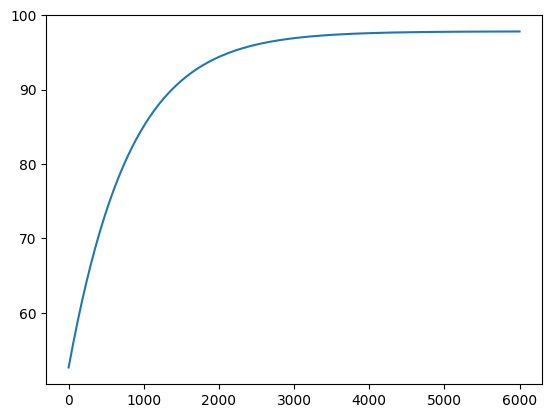

In [144]:
# IEEE 738
#X1 = ieee738.IEEE738()
X1.set_case( Case1)
X1.Debug = 0
#X1.set_cable( Cable1)
#X1.set_case( Case1)
X1.Case1.ATCDR = []
X1.Case1.TIME = []
X1.Case1.NSELECT = 3
X1.Case1.XIPRELOAD = 100
X1.Case1.XISTEP = 1000

X1.Case1.TT = 6000
X1.Case1.SORM = 1
X1.Case1.DELTIME = 60

X1.ieee_738_2013()
X1.outputs()



plt.plot( X1.Case1.TIME, X1.Case1.ATCDR)
ATCDRieee = X1.Case1.ATCDR
Time = X1.Case1.TIME

#

steps:  100
Tinitial:  55.40666355824186  ; dT:  0.032667332131606504
Tinitial:  55.43933089037347  ; dT:  3.522243187463817
Tinitial:  58.961574077837284  ; dT:  3.255778083327356
Tinitial:  62.21735216116464  ; dT:  3.0066784388810186
Tinitial:  65.22403060004567  ; dT:  2.7742081613117455
Tinitial:  67.99823876135741  ; dT:  2.557606426943371
Tinitial:  70.55584518830078  ; dT:  2.3560969926486095
Tinitial:  72.91194218094938  ; dT:  2.168896788842788
Tinitial:  75.08083896979217  ; dT:  1.995223666103909
Tinitial:  77.07606263589608  ; dT:  1.8343032228648855
Tinitial:  78.91036585876097  ; dT:  1.6853746875184963
Tinitial:  80.59574054627946  ; dT:  1.5476958647978782
Tinitial:  82.14343641107733  ; dT:  1.4205471840617259
Tinitial:  83.56398359513906  ; dT:  1.3032349070488776
Tinitial:  84.86721850218794  ; dT:  1.1950935658603308
Tinitial:  86.06231206804827  ; dT:  1.0954877095176465
Tinitial:  87.15779977756591  ; dT:  1.003813040543845
Tinitial:  88.16161281810976  ; dT:  0.

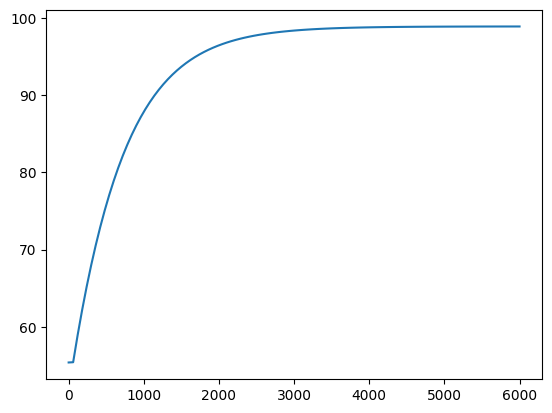

In [145]:
X2.Case1.NSELECT = 3
X2.Case1.XIPRELOAD = 100
X2.Case1.XISTEP = 1000
X2.Case1.TT = 100
X2.Case1.SORM = 1
X2.Case1.DELTIME = 60
X2.Case1.TIME = []
X2.Case1.ATCDR = []
X2.Debug = 0
X2.cigre601()
#X2.outputs()

plt.plot( X2.Case1.TIME, X2.Case1.ATCDR)
ATCDRcigre = X2.Case1.ATCDR 


In [146]:
#plt.plot( Time, ATCDRieee, Time, ATCDRcigre)

len(ATCDRcigre)

101